### Vivaldi antenna

Full parametric Vivaldi antenna mesh using gmsh/OpenCASCADE.

The exponential taper profile follows:
$$y = \pm\frac{w_s}{2} \cdot e^{C(x - x_0)}$$
where $C$ is the opening rate (25 here) and $x_0$ is the taper start.

**Coordinate convention** (matches the diagram, x is the long axis):
- Ground plane centred at origin in XY plane
- Aperture opens toward +x
- Cavity is on the −x side
- Z is vertical (substrate thickness)

In [1]:
import gmsh
import math
import numpy as np
from palacetoolkit.mesh import (
    Entity, 
    run_meshing_pipeline, 
    generate_3d_mesh, 
    refine_near_surfaces
)
from palacetoolkit.viz import run_with_scrollable_output, view_mesh       


#### Antenna parameters

In [2]:
taper_length:        float = 0.243     
aperture_width:      float = 0.105     
opening_rate:        float = 25.0      
slot_width:          float = 5e-4      
cavity_diameter:     float = 0.024     
cavity_to_taper:     float = 0.023     
ground_plane_length: float = 0.300     
ground_plane_width:  float = 0.125      
h_sub:               float = 0.015     
air_height:          float = 0.025     
air_margin:          float = 0.025

freq_ghz = 4.5
c0 = 3e8
wavelength = c0 / (freq_ghz * 1e9)

mesh_file = "vivaldi.msh"

# Derived coordinates
Lx = ground_plane_length
Ly = ground_plane_width

# Left edge of the ground plane.
x0 = -Lx/2                

# Right edge of the ground plane.
x1 =  Lx/2                

# x_taper_start: where the exponential section begins
x_taper_start = x1 - taper_length

# x_slot_left: start of parallel section = end of cavity = x_taper_start - s
x_slot_left = x_taper_start - cavity_to_taper

# cavity centre
x_cav = x_slot_left - cavity_diameter / 2

print(f"Ground plane:      [{x0:.4f}, {x1:.4f}]")
print(f"Taper starts at:    x = {x_taper_start:.4f}")
print(f"Parallel section:   x = [{x_slot_left:.4f}, {x_taper_start:.4f}]  "
      f"length = {cavity_to_taper*1e3:.1f} mm  (= cavity_to_taper)")
print(f"Cavity centre at:   x = {x_cav:.4f}")
print(f"Cavity right edge:  x = {x_slot_left:.4f}  (= x_taper_start - s)")


Ground plane:      [-0.1500, 0.1500]
Taper starts at:    x = -0.0930
Parallel section:   x = [-0.1160, -0.0930]  length = 23.0 mm  (= cavity_to_taper)
Cavity centre at:   x = -0.1280
Cavity right edge:  x = -0.1160  (= x_taper_start - s)


#### Exponential taper mathematics

The upper edge of the Vivaldi slot follows:
$$y_{\text{upper}}(x) = \frac{w_s}{2} \cdot e^{C(x - x_{\text{ts}})}$$
scaled so that $y_{\text{upper}}(x_1) = w_a/2$.

We solve for the normalisation constant $A$:
$$A = \frac{w_a/2}{e^{C(x_1 - x_{\text{ts}})}}$$
which gives:
$$y_{\text{upper}}(x) = A \cdot e^{C(x - x_{\text{ts}})}$$

The lower edge is the mirror: $y_{\text{lower}} = -y_{\text{upper}}$.

In [3]:
def taper_y(x: float, sign: float = 1.0) -> float:
    
    # Normalisation: amplitude A chosen so y(x1) = aperture_width/2
    A = (aperture_width / 2) / math.exp(opening_rate * (x1 - x_taper_start))
    
    return sign * A * math.exp(opening_rate * (x - x_taper_start))

# Quick sanity checks
print(f"y at taper start : {taper_y(x_taper_start):+.5f}  (expected ≈ {slot_width/2:+.5f})")
print(f"y at aperture    : {taper_y(x1):+.5f}  (expected ≈ {aperture_width/2:+.5f})")

y at taper start : +0.00012  (expected ≈ +0.00025)
y at aperture    : +0.05250  (expected ≈ +0.05250)


#### Initialise gmsh

In [4]:
gmsh.initialize()
gmsh.model.add("vivaldi_antenna")
kernel = gmsh.model.occ   

#### Build the 3-D volumes (substrate + air box)

In [5]:
# Bounding box extents 
total_xmin = x0 - air_margin
total_xmax = x1 + air_margin
total_ymin = -Ly/2 - air_margin
total_ymax =  Ly/2 + air_margin
total_zmax = h_sub + air_height

# Substrate 
substrate = kernel.addBox(
    x0, -Ly/2, 0,
    Lx,  Ly,   h_sub
)

# Air_box 
air_box = kernel.addBox(
    total_xmin, total_ymin, 0,
    total_xmax - total_xmin,
    total_ymax - total_ymin,
    total_zmax
)

print("Substrate tag:", substrate)
print("Air box tag:  ", air_box)

Substrate tag: 1
Air box tag:   2


#### Build the copper patch (ground plane + taper slot + cavity)

Strategy:
1. Start with a full rectangular ground-plane surface.
2. Subtract the exponential slot (built from a spline boundary).
3. Subtract the circular cavity.
4. The result is the physical copper surface at z = h_sub.

In [6]:
# Top rectangle. We´ll cut the slot and cavity out of this.
top_rect = kernel.addRectangle(x0, -Ly/2, h_sub, Lx, Ly)

# Parallel section geometry.
p_ul = kernel.addPoint(x_slot_left,   +slot_width/2, h_sub)
p_ur = kernel.addPoint(x_taper_start, +slot_width/2, h_sub)
p_lr = kernel.addPoint(x_taper_start, -slot_width/2, h_sub)
p_ll = kernel.addPoint(x_slot_left,   -slot_width/2, h_sub)

# Straight lines
line_top_par = kernel.addLine(p_ul, p_ur)   # upper parallel edge
line_bot_par = kernel.addLine(p_lr, p_ll)   # lower parallel edge (reversed for CCW)
line_left    = kernel.addLine(p_ll, p_ul)   # left closing line (at x_slot_left)

# Interpolate points along the exponential taper curve from x_taper_start to x1.
N_pts = 100
xs = np.linspace(x_taper_start, x1, N_pts)

# Upper spline
upper_inner = [kernel.addPoint(float(x), taper_y(float(x), +1.0), h_sub)
               for x in xs[1:]]
upper_spline = kernel.addSpline([p_ur] + upper_inner)

# Lower spline: starts at p_lr, reversed direction for CCW loop.
lower_inner = [kernel.addPoint(float(x), taper_y(float(x), -1.0), h_sub)
               for x in xs[1:]]

# In the loop we traverse lower in reverse (aperture → taper_start),
# so we list points aperture-end first.
lower_spline = kernel.addSpline(lower_inner[::-1] + [p_lr])

# Aperture closing line (right edge, x = x1)
p_apt = upper_inner[-1]   # top-right aperture point
p_apb = lower_inner[-1]   # bottom-right aperture point
line_aperture = kernel.addLine(p_apt, p_apb)

slot_loop = kernel.addCurveLoop([
    line_left,        # up the left edge  (x_slot_left, bot→top)
    line_top_par,     # rightward along upper parallel
    upper_spline,     # upper exponential curve to aperture
    line_aperture,    # down the aperture edge
    lower_spline,     # lower exponential back to x_taper_start (reversed)
    line_bot_par,     # leftward along lower parallel back to start
])

slot_surf = kernel.addPlaneSurface([slot_loop])

# Circular cavity
cav_r  = cavity_diameter / 2
cav_cx = x_cav
cav_cy = 0.0

cav_circle = kernel.addCircle(cav_cx, cav_cy, h_sub, cav_r)
cav_loop   = kernel.addCurveLoop([cav_circle])
cav_surf   = kernel.addPlaneSurface([cav_loop])

print(f"Parallel section:  x=[{x_slot_left:.4f}, {x_taper_start:.4f}]  y=±{slot_width/2:.5f}")
print(f"Exponential section: x=[{x_taper_start:.4f}, {x1:.4f}]")
print(f"Aperture width at x1: {2*taper_y(x1,1)*1e3:.2f} mm  (target {aperture_width*1e3:.2f} mm)")
print("Top rectangle tag: ", top_rect)
print("Slot surface tag:      ", slot_surf)
print("Cavity surface tag:    ", cav_surf)

Parallel section:  x=[-0.1160, -0.0930]  y=±0.00025
Exponential section: x=[-0.0930, 0.1500]
Aperture width at x1: 105.00 mm  (target 105.00 mm)
Top rectangle tag:  13
Slot surface tag:       14
Cavity surface tag:     15


#### Feed port

From the inset diagram, the feed port is a **square face** in the YZ plane
at the left edge of the ground plane (`x = x0`).  It is centred on the slot
(`y = 0`) and spans the substrate thickness in z.

- `feed_offset` is the **x-axis** offset that positions where along the slot
  the port is referenced — here it locates the port at `x = x0 + feed_offset`
  inside the ground plane, but the excitation face itself sits flush at
  `x = x0` (the left wall of the computational domain).
- The port is square: width = height = `slot_width` in the YZ cross-section.
- It is centred at `y = 0, z = h_sub / 2` (mid-height of the substrate).

In [7]:
port_size    = slot_width                    # square side length [m]
port_x_ctr   = x_taper_start - port_size / 2 # port centre along x
port_x0      = port_x_ctr - port_size / 2    # left x of port
port_y0      = -port_size / 2                 # bottom y (centred on slot)

# Flat XY-plane rectangle at z = h_sub — no rotation needed.
feed_port_surf = kernel.addRectangle(
    port_x0,    # x start
    port_y0,    # y start  (centred: -w_s/2 .. +w_s/2)
    h_sub,      # z = top of substrate
    port_size,  # dx = slot_width  (square in x)
    port_size,  # dy = slot_width  (square in y, touches both copper edges)
)

print(f"Feed port surface tag: {feed_port_surf}")
print(f"Port centre: x={port_x_ctr:.4f}  y=0  z={h_sub:.5f} (top of substrate)")
print(f"Port x range: [{port_x0:.4f}, {port_x0+port_size:.4f}]")
print(f"Port y range: [{port_y0:.5f}, {-port_y0:.5f}]")
print(f"Port size: {port_size*1e3:.2f} mm × {port_size*1e3:.2f} mm (square)")
print(f"Sanity: port_x_ctr ({port_x_ctr:.4f}) should be between "
       f"cavity right edge ({x_cav + cavity_diameter/2:.4f}) "
       f"and taper start ({x_taper_start:.4f})")

Feed port surface tag: 16
Port centre: x=-0.0932  y=0  z=0.01500 (top of substrate)
Port x range: [-0.0935, -0.0930]
Port y range: [-0.00025, 0.00025]
Port size: 0.50 mm × 0.50 mm (square)
Sanity: port_x_ctr (-0.0932) should be between cavity right edge (-0.1160) and taper start (-0.0930)


#### Boolean operations — assemble the copper patch

Cut the slot and cavity out of the ground-plane rectangle.
The feed strip is kept separate (it is a distinct conductor patch).

In [8]:
kernel.synchronize()

# Cut slot + cavity from ground-plane rectangle
# BooleanCut returns (result_dimtags, map)
copper_patch, _ = kernel.cut(
    [(2, top_rect)],                         # object: full rectangle
    [(2, slot_surf), (2, cav_surf)],         # tools: slot + cavity
    removeObject=True, removeTool=True
)

kernel.synchronize()
print("Copper patch surfaces after boolean cut:")
for dim, tag in copper_patch:
    print(f"  dim={dim}, tag={tag}")

Info    : [  0%] Difference                                                                                  
Info    : [ 10%] Difference                                                                                  
Info    : [ 20%] Difference                                                                                  
Info    : [ 30%] Difference                                                                                  
Info    : [ 40%] Difference                                                                                  
Info    : [ 50%] Difference                                                                                  
Info    : [ 70%] Difference - Filling splits of edges                                                                                
Info    : [ 80%] Difference - Making faces                                                                                
Info    : [ 90%] Difference - Adding holes                                         

#### Entity definition. 

In order to get a good mesh we need to fragment it and restore it, run_meshing_pipeline does this and also defines the physical groups.

In [9]:
entities = [
    Entity("copper_patch", dim=2, mesh_order = 1, tags=[copper_patch[0][1]]),
    Entity("substrate", dim=3, mesh_order=1, tags=[substrate]),
    Entity("air_box", dim=3, mesh_order = 2, tags=[air_box]),
    Entity("feed_port", dim=2, mesh_order=0, tags=[feed_port_surf]),
]

pg_map = run_meshing_pipeline(entities)
refine_near_surfaces(entities[-1].dimtags, wavelength, ppw_near=30, ppw_far=15, set_as_background=True)

mesh_sizes = {
    "substrate": wavelength / 12,
    "air_box": wavelength / 4,
    "feed_port": wavelength / 18,
    "copper_patch": wavelength / 12,
}

generate_3d_mesh(entities, mesh_sizes, mesh_file, optimize=True)
gmsh.option.setNumber("Mesh.MshFileVersion", 2.2)
gmsh.write(mesh_file)
gmsh.finalize()

Info    : [  0%] Difference                                                                                  
Info    : [ 10%] Difference                                                                                  
Info    : [ 20%] Difference                                                                                  
Info    : [ 30%] Difference                                                                                  
Info    : [ 40%] Difference                                                                                  
Info    : [ 50%] Difference                                                                                  
Info    : [ 60%] Difference                                                                                  
Info    : [ 70%] Difference - Filling splits of edges                                                                                
Info    : [ 80%] Difference - Adding holes                                                      

Info    : [ 10%] Meshing surface 16 (Plane, MeshAdapt)
Info    : [ 20%] Meshing surface 17 (Plane, MeshAdapt)
Info    : [ 20%] Meshing surface 18 (Plane, MeshAdapt)
Info    : [ 30%] Meshing surface 19 (Plane, MeshAdapt)
Info    : [ 40%] Meshing surface 20 (Plane, MeshAdapt)


Info    : [ 40%] Meshing surface 21 (Plane, MeshAdapt)


Info    : [ 50%] Meshing surface 22 (Plane, MeshAdapt)
Info    : [ 60%] Meshing surface 23 (Plane, MeshAdapt)
Info    : [ 60%] Meshing surface 24 (Plane, MeshAdapt)
Info    : [ 70%] Meshing surface 25 (Plane, MeshAdapt)
Info    : [ 70%] Meshing surface 26 (Plane, MeshAdapt)
Info    : [ 80%] Meshing surface 27 (Plane, MeshAdapt)


Info    : [ 90%] Meshing surface 28 (Plane, MeshAdapt)
Info    : [ 90%] Meshing surface 29 (Plane, MeshAdapt)
Info    : [100%] Meshing surface 30 (Plane, MeshAdapt)
Info    : Done meshing 2D (Wall 0.502565s, CPU 0.503138s)
Info    : Meshing 3D...
Info    : 3D Meshing 2 volumes with 1 connected component
Info    : Tetrahedrizing 13439 nodes...


...

Info    : 0 splits performed 
Info    : ImproveMesh 
Info    : Total badness = 122485 
Info    : Total badness = 122477 
Info    : SwapImprove  


Info    : 324 swaps performed 
Info    : SwapImprove2  


Info    : 0 swaps performed 
Info    : ImproveMesh 
Info    : Total badness = 122328 
Info    : Total badness = 122152 


Info    : Done optimizing mesh (Wall 6.71009s, CPU 6.72539s)
Info    : Writing 'vivaldi.msh'...
Mesh saved to vivaldi.msh
Info    : Done writing 'vivaldi.msh'
  Nodes: 27656


  Elements: 160232
Info    : Writing 'vivaldi.msh'...
Info    : Done writing 'vivaldi.msh'


#### Mesh generation

Loading mesh file: vivaldi.msh
Groups to render transparent: air_box__None



Mesh loaded successfully with 2 cell blocks
Found 27066 triangles total
Physical group tags in mesh: {3: 'copper_patch', 4: 'feed_port', 5: 'air_box__substrate', 6: 'substrate__None', 7: 'air_box__None'}



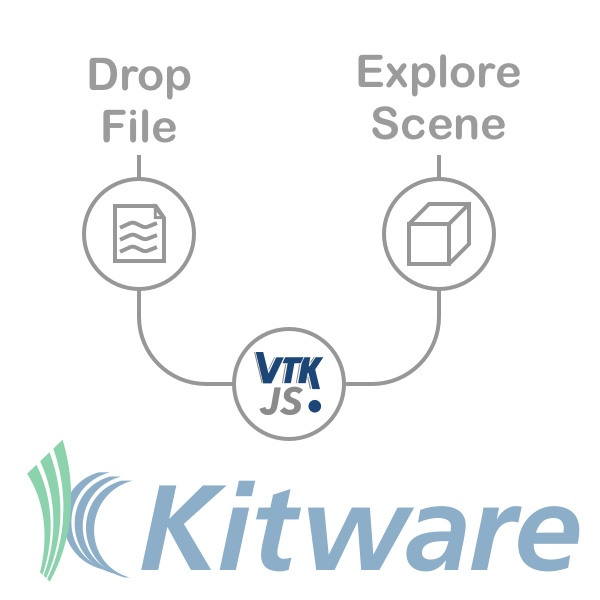

In [10]:
import pyvista as pv

# trame for interactive visualization in the notebook.
pv.set_jupyter_backend("trame")

# Visualize the mesh in the notebook.
view_mesh(mesh_file, transparent_groups="air_box__None")